# KID notebook 
this is the fid notebook, updated to test kid 
- needs access  to file netG_epoch_199.pth

## Data and model loading 

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import numpy as np
import torch
from torchvision import transforms
import scipy
from Datasets.DCGANDataset import GANDataLoader
from Datasets.Cifar_10dataset import CIFAR10FIDDataset
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision.utils as vutils
import torch.backends.cudnn as cudnn
import torch.optim as optim
from torchvision.utils import save_image
from torch.autograd import Variable
import matplotlib.pyplot as plt
import pylab
from Models.dcgan import Discriminator, Generator
from torchvision import models
from torch import nn
from scipy.linalg import sqrtm


In [3]:

#looks like code they used for cifar-XX access
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [4]:
from torchvision.datasets import CIFAR10

dataset = CIFAR10(root="data", download=True)

Files already downloaded and verified


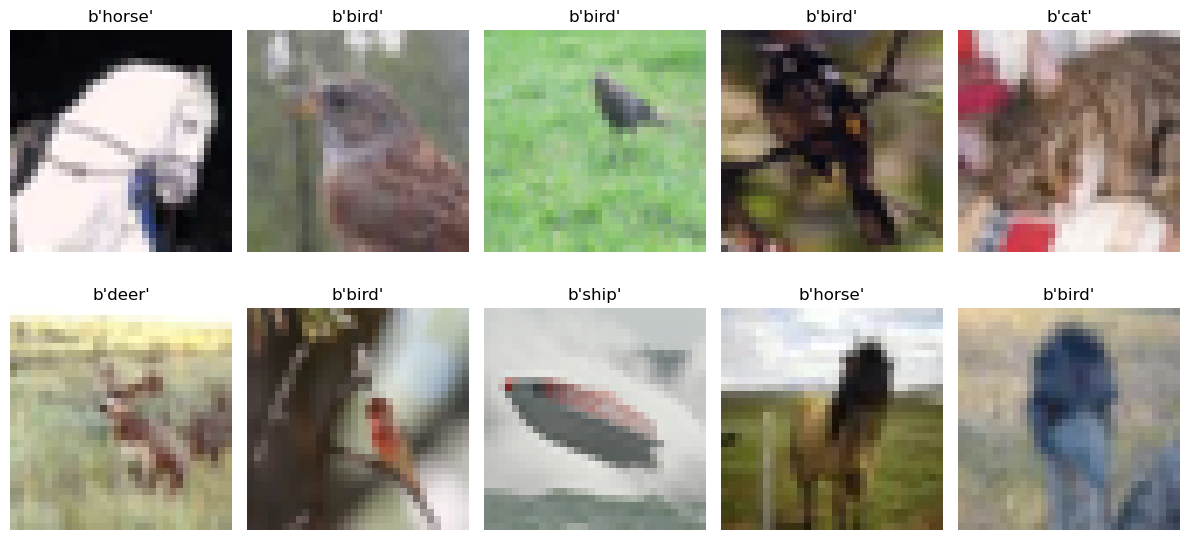

In [5]:
#loading cifar-10 dataset
directory = "data/cifar-10-batches-py/batches.meta"

meta_data = unpickle(directory)

class_names = meta_data[b'label_names']

# 2. Load just the first data batch for visualization
batch1 = unpickle("data/cifar-10-batches-py/test_batch")
images = batch1[b'data']
labels = batch1[b'labels']

# 3. Reshape the data
# The raw data is a flat array of 3072 numbers (32*32*3)
# It is stored as (Channels, Height, Width) so we reshape then transpose to (H, W, C)
images = images.reshape(len(images), 3, 32, 32).transpose(0, 2, 3, 1)

# 4. Plot 10 random images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(images))
    ax.imshow(images[idx])
    ax.set_title(class_names[labels[idx]])
    ax.axis('off')

plt.tight_layout()
plt.show()


Dataset length: 10000
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 299, 299])
Sample dtype: torch.float32
Sample min: -1.878
Sample max: 2.570
Batch shape: torch.Size([64, 3, 299, 299])
Has NaN: False
Has Inf: False


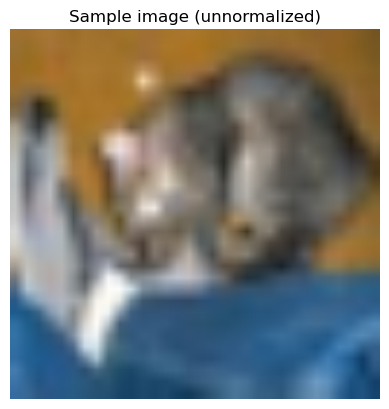

In [8]:
#testing CIFAR-10 dataloader

#transform should be for the inception V3 model
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Quick Tests ---
dataset = CIFAR10FIDDataset(batch1, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)


total_size = len(dataset)
indices = np.random.choice(total_size, 100, replace=False)

subset_Cifar10 = SubsetRandomSampler(indices)
randsubsample = DataLoader(dataset, batch_size=32, sampler=subset_Cifar10)



# 1. Dataset length
print(f"Dataset length: {len(dataset)}")  # expect 10000

# 2. Single sample shape and type
sample = dataset[0]
print(f"Sample type: {type(sample)}")          # <class 'torch.Tensor'>
print(f"Sample shape: {sample.shape}")         # torch.Size([3, 299, 299])
print(f"Sample dtype: {sample.dtype}")         # torch.float32

# 3. Value range after normalization (should be roughly -2.1 to 2.6)
print(f"Sample min: {sample.min():.3f}")
print(f"Sample max: {sample.max():.3f}")

# 4. First DataLoader batch
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")           # torch.Size([64, 3, 299, 299])

# 5. No NaNs or Infs
print(f"Has NaN: {torch.isnan(batch).any()}")  # False
print(f"Has Inf: {torch.isinf(batch).any()}")  # False

# 6. Visual check — show first image unnormalized
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_unnorm = (dataset[0] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

plt.imshow(img_unnorm)
plt.title("Sample image (unnormalized)")
plt.axis("off")
plt.show()

In [9]:
#load DCGAN
# num_gpu = 1 if torch.cuda.is_available() else 0
dira = "netG_epoch_199.pth"

# load the models

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G.load_state_dict(torch.load(dira, map_location=device))
G = G.to(device)

# load weights
#D.load_state_dict(torch.load(''))

if torch.cuda.is_available():
    D = D.cuda()
    G = G.cuda()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

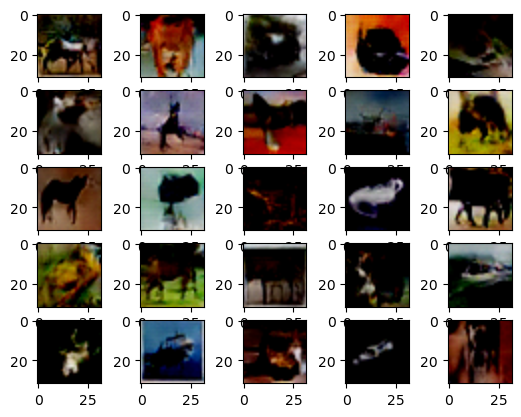

In [10]:
#testing DCGAN

batch_size = 25
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1)
if torch.cuda.is_available():
    fixed_noise = fixed_noise.cuda()
fake_images = G(fixed_noise)


# z = torch.randn(batch_size, latent_size).cuda()
# z = Variable(z)
# fake_images = G(z)

fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 3, 32, 32)
fake_images_np = fake_images_np.transpose((0, 2, 3, 1))
R, C = 5, 5
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.imshow(fake_images_np[i], interpolation='bilinear')
plt.show()


In [11]:
# Source - https://stackoverflow.com/a/51014127
# Posted by M. Deckers, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-02, License - CC BY-SA 4.0

#creating the GAN dataloader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


gen_loader = GANDataLoader(
    generator=G,
    latent_dim=100,
    batch_size=20,#64,
    num_batches= 5,#157,   # 157 * 64 ≈ 10000 to match your real dataset size
    device=device
)
i= 0
for batch in gen_loader:
    # batch is [64, 3, H, W] — pass to Inception for FID
    print(i+1)
    i = i+1 


1
2
3
4
5


In [12]:
#extracting the features in the data using inception v3 model
def extract_features_from_dataloader(dataloader, model, device):
    model.to(device)
    features = []
    
    with torch.no_grad():
        for batch in dataloader:
            # Assuming batch is (images, labels) or just images
            imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
            feat = model(imgs)
            features.append(feat.cpu().numpy())
            
    return np.concatenate(features, axis=0)


In [13]:
#loading inception-V3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#shove the important data with all the matrices of the cifar-10 dataset into a numpy array

incept_model = models.inception_v3(weights='Inception_V3_Weights.IMAGENET1K_V1')

# Set to evaluation mode (important for Batch Normalization and Dropout)
incept_model.eval()

# Remove the final classification layer (Linear layer)
# This ensures the output is the 2048-d feature vector from the pooling layer
incept_model.fc = nn.Identity()
   
# Disable auxiliary logits for inference
incept_model.aux_logits = False

incept_model = incept_model.to(device)



In [14]:
real_processed_feat = extract_features_from_dataloader(randsubsample, incept_model, device)
gen_processed_feat = extract_features_from_dataloader(gen_loader, incept_model, device)

real_mean = np.mean(real_processed_feat, axis = 1)
real_cov = np.cov(real_processed_feat)
gen_mean = np.mean(gen_processed_feat, axis = 1)
gen_cov = np.cov(gen_processed_feat)

## KID part 

In [ ]:
from __future__ import annotations
import numpy as np



def polynomial_kernel(x: np.ndarray,y: np.ndarray):
    d = x.shape[1] # kernel on feature dimension
    return ((1/d)*(x @ y.T)+ 1 )**3

def kid(real_features: np.ndarray, fake_features: np.ndarray):
    m= real_features.shape[0] # comparing based on samples
    n= fake_features.shape[0]

    Kxx = polynomial_kernel(real_features,real_features)
    sum_Kxx=  np.sum(Kxx) - np.trace(Kxx) # we need this so it is not biased
    Kyy = polynomial_kernel(fake_features,fake_features)
    sum_Kyy=  np.sum(Kyy) - np.trace(Kyy)

    sum_Kxy = np.sum(polynomial_kernel(real_features,fake_features))

    kid = (1/(m*(m-1)))*sum_Kxx +(1/(n*(n-1)))*sum_Kyy  - 2*(1/(n*m))*sum_Kxy

    return float(kid)

def compute_kid(real_features: np.ndarray, fake_features: np.ndarray):
    KIDs= []
    for _ in range(100):
        random_real = np.random.choice(real_features.shape[0], 1000)
        random_fake = np.random.choice(fake_features.shape[0], 1000)
        sampled_kid = kid(real_features[random_real], fake_features[random_fake])
        KIDs.append(sampled_kid)

    return np.mean(KIDs) , np.std(KIDs)


print(compute_kid(real_processed_feat,gen_processed_feat))

(0.03281362847847842, 0.0012273882930940638)


### KID library

In [ ]:
# probably need to run this too 
pip install torchmetrics[image]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
from torchmetrics.image.kid import KernelInceptionDistance
kid = KernelInceptionDistance(subset_size=100)

# using randomly generated images
img1 = torch.randint(0, 200, (100, 3, 299, 299), dtype=torch.uint8)
img2 = torch.randint(100, 255, (100, 3, 299, 299), dtype=torch.uint8)

kid.update(img1, real=True)
kid.update(img2, real=False)
kid_mean, kid_std = kid.compute()
print((kid_mean, kid_std))


(tensor(0.0300), tensor(2.2742e-07))
